In [1]:
# Notebooks use their own directory as the working directory by default.
# We change it to the project root so that relative paths (e.g. data/) work correctly.
%cd ..

/home/urbans50/projects/nn_2026_template


In [2]:
import fiddle as fdl
import lightning as L
import matplotlib.pyplot as plt

from src.config.convnet_utkface_classifier import build_config

In [3]:
class MetricsCallback(L.Callback):
    def __init__(self):
        self.train_metrics = []
        self.val_metrics = []

    def on_train_epoch_end(self, trainer, pl_module):
        self.train_metrics.append({
            k: v.item() for k, v in trainer.callback_metrics.items()
            if k.startswith("train/")
        })

    def on_validation_epoch_end(self, trainer, pl_module):
        if trainer.sanity_checking:
            return
        self.val_metrics.append({
            k: v.item() for k, v in trainer.callback_metrics.items()
            if k.startswith("val/")
        })

In [4]:
L.seed_everything(42)

cfg = build_config()
built_cfg = fdl.build(cfg)

metrics_cb = MetricsCallback()

trainer = L.Trainer(
    max_epochs=built_cfg.training_cfg.max_epochs,
    callbacks=[metrics_cb],
    log_every_n_steps=10,
    enable_progress_bar=True,
)
trainer.fit(model=built_cfg.model, datamodule=built_cfg.data_module)

Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
/home/urbans50/.micromamba/envs/nn_2026_template/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to e

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/urbans50/.micromamba/envs/nn_2026_template/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/urbans50/.micromamba/envs/nn_2026_template/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.


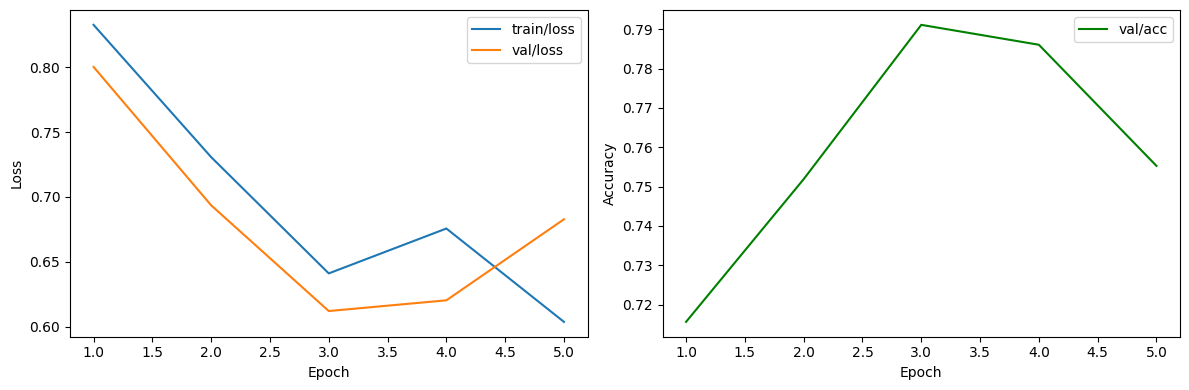

In [5]:
epochs = range(1, len(metrics_cb.val_metrics) + 1)
train_loss = [m["train/loss"] for m in metrics_cb.train_metrics]
val_loss   = [m["val/loss"]   for m in metrics_cb.val_metrics]
val_acc    = [m["val/acc"]    for m in metrics_cb.val_metrics]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, train_loss, label="train/loss")
ax1.plot(epochs, val_loss,   label="val/loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(epochs, val_acc, label="val/acc", color="green")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()

plt.tight_layout()
plt.show()